Training classification models (N=2000, Epochs=200, Noise=0.35)...
Saving Animation Files...


/var/folders/3z/qhljkmbd5mz1q930tpfcbdyh0000gn/T/ipykernel_7429/3404008132.py:167: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour[0].collections:


✓ Saved MP4: classification_decision_boundary.mp4


/var/folders/3z/qhljkmbd5mz1q930tpfcbdyh0000gn/T/ipykernel_7429/3404008132.py:167: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  for c in contour[0].collections:


✓ Saved GIF: classification_decision_boundary.gif


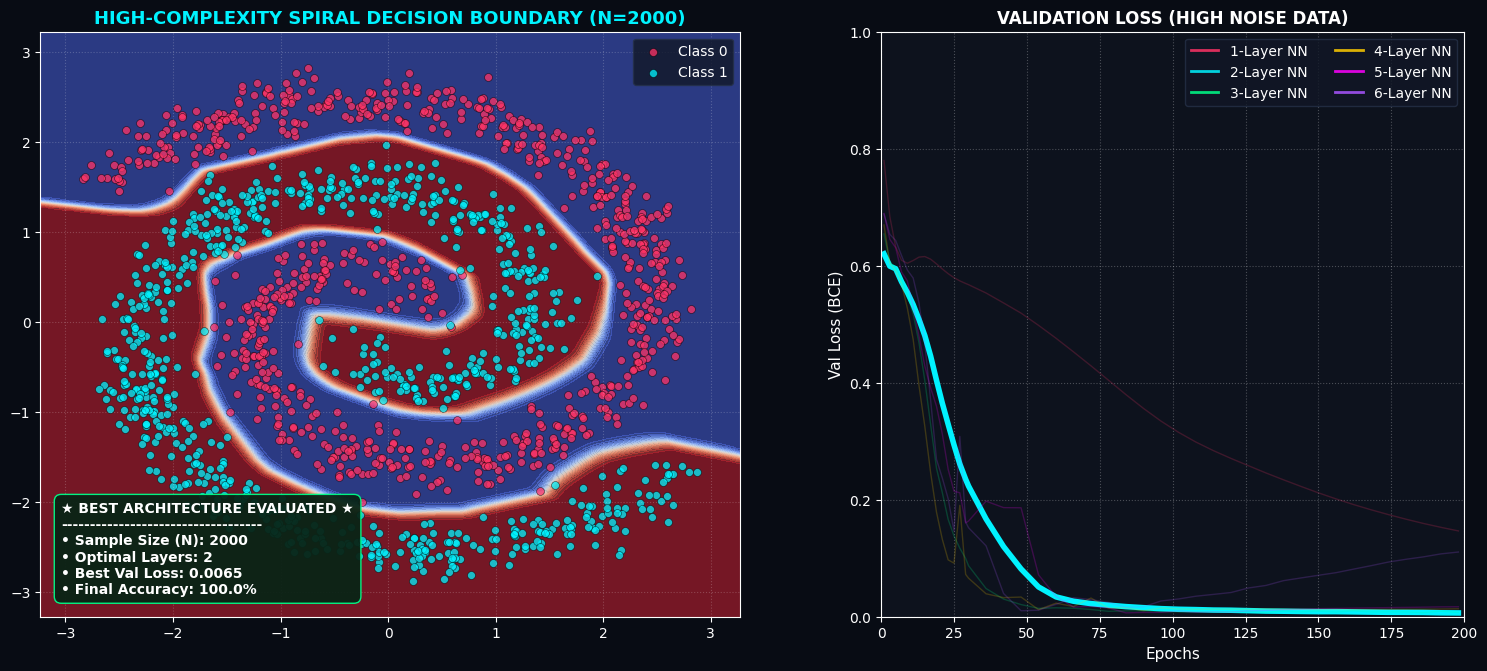

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.model_selection import train_test_split
import imageio_ffmpeg

# Set FFmpeg path from imageio
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

# --- 1. Complex Data Generation (Double Spiral - N=2000, Noise=0.35) ---
np.random.seed(42)
torch.manual_seed(42)

def generate_spiral_data(n_samples=2000, noise=0.35):
    n = n_samples // 2
    # Spiral 1 (Class 0)
    theta1 = np.sqrt(np.random.rand(n)) * 2.8 * np.pi
    r1 = 2 * theta1 + 1
    x1 = np.array([r1 * np.cos(theta1), r1 * np.sin(theta1)]).T
    x1 += np.random.randn(n, 2) * noise * 3.0

    # Spiral 2 (Class 1)
    theta2 = np.sqrt(np.random.rand(n)) * 2.8 * np.pi
    r2 = -2 * theta2 - 1
    x2 = np.array([r2 * np.cos(theta2), r2 * np.sin(theta2)]).T
    x2 += np.random.randn(n, 2) * noise * 3.0

    X = np.vstack((x1, x2))
    y = np.hstack((np.zeros(n), np.ones(n)))
    
    # Normalize features
    X = (X - X.mean(axis=0)) / X.std(axis=0) * 1.5
    return X, y

# Generate 2000 samples with noise=0.35
X_raw, y_raw = generate_spiral_data(n_samples=2000, noise=0.35)

# Train/Val Split
X_tr, X_val, y_tr, y_val = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Meshgrid for visualising decision boundaries
x_min, x_max = X_raw[:, 0].min() - 0.4, X_raw[:, 0].max() + 0.4
y_min, y_max = X_raw[:, 1].min() - 0.4, X_raw[:, 1].max() + 0.4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 220),
                     np.linspace(y_min, y_max, 220))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
grid_t = torch.tensor(grid_points, dtype=torch.float32)

# --- 2. Neural Network Models ---
class ComplexClassificationNN(nn.Module):
    def __init__(self, num_layers, hidden_dim=64):
        super(ComplexClassificationNN, self).__init__()
        layers = []
        in_dim = 2
        for _ in range(num_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.ReLU())
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

layer_configs = [1, 2, 3, 4, 5, 6]
models = [ComplexClassificationNN(num_layers=l, hidden_dim=64) for l in layer_configs]
optimizers = [optim.Adam(m.parameters(), lr=0.01) for m in models]
criterion = nn.BCEWithLogitsLoss()

# Total epochs set to 200
total_epochs = 200
saved_epochs = list(range(1, 30, 2)) + list(range(30, total_epochs + 1, 6))

history = {l: {'grid_probs': [], 'val_loss': [], 'val_acc': []} for l in layer_configs}

print("Training classification models (N=2000, Epochs=200, Noise=0.35)...")
for idx, l in enumerate(layer_configs):
    model = models[idx]
    opt = optimizers[idx]
    
    for epoch in range(1, total_epochs + 1):
        model.train()
        opt.zero_grad()
        logits_tr = model(X_tr_t)
        loss = criterion(logits_tr, y_tr_t)
        loss.backward()
        opt.step()

        if epoch in saved_epochs:
            model.eval()
            with torch.no_grad():
                grid_logits = model(grid_t)
                grid_probs = torch.sigmoid(grid_logits).numpy().reshape(xx.shape)
                
                val_logits = model(X_val_t)
                val_loss = criterion(val_logits, y_val_t).item()
                val_preds = (torch.sigmoid(val_logits) >= 0.5).float()
                val_acc = (val_preds == y_val_t).float().mean().item()

                history[l]['grid_probs'].append(grid_probs)
                history[l]['val_loss'].append(val_loss)
                history[l]['val_acc'].append(val_acc)

best_val_losses = {l: min(history[l]['val_loss']) for l in layer_configs}
best_layer = min(best_val_losses, key=best_val_losses.get)

# --- 3. Animation Setup ---
plt.style.use('dark_background')
BG_DARK = '#080c14'
PANEL_DARK = '#0d121d'

fig, (ax_boundary, ax_loss) = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={'width_ratios': [1.2, 1]}, dpi=100)
fig.patch.set_facecolor(BG_DARK)
fig.subplots_adjust(wspace=0.22, left=0.06, right=0.95, top=0.88, bottom=0.1)

ax_boundary.set_facecolor(PANEL_DARK)
ax_loss.set_facecolor(PANEL_DARK)

colors = ['#ff3366', '#00f3ff', '#00ff88', '#ffcc00', '#ff00ff', '#aa55ff']

# Boundary Plot Base Setup
ax_boundary.set_xlim(x_min, x_max)
ax_boundary.set_ylim(y_min, y_max)
ax_boundary.set_title("HIGH-COMPLEXITY SPIRAL DECISION BOUNDARY (N=2000)", fontsize=13, fontweight='bold', color='#00f3ff')

# Scatter Data Points - Larger size (s=32) for prominent, sharp visual effect
ax_boundary.scatter(X_tr[y_tr == 0, 0], X_tr[y_tr == 0, 1], color='#ff3366', edgecolors='k', linewidths=0.4, alpha=0.75, s=32, label='Class 0')
ax_boundary.scatter(X_tr[y_tr == 1, 0], X_tr[y_tr == 1, 1], color='#00f3ff', edgecolors='k', linewidths=0.4, alpha=0.75, s=32, label='Class 1')
ax_boundary.legend(loc='upper right', facecolor='#111726', edgecolor='#253047')
ax_boundary.grid(True, linestyle=':', alpha=0.2)

contour = [ax_boundary.contourf(xx, yy, np.zeros_like(xx), levels=10, cmap='coolwarm', alpha=0.4, zorder=0)]

# Loss Plot Setup - Fixed xlim to 200
ax_loss.set_title("VALIDATION LOSS (HIGH NOISE DATA)", fontsize=12, fontweight='bold', color='white')
loss_lines = [ax_loss.plot([], [], color=colors[i], linewidth=2.0, alpha=0.85, label=f'{l}-Layer NN')[0] 
              for i, l in enumerate(layer_configs)]

ax_loss.set_xlim(0, total_epochs) # 200 epochs
ax_loss.set_ylim(0, 1.0)
ax_loss.set_xlabel("Epochs", fontsize=11)
ax_loss.set_ylabel("Val Loss (BCE)", fontsize=11)
ax_loss.legend(loc='upper right', ncol=2, facecolor='#111726', edgecolor='#253047')
ax_loss.grid(True, linestyle=':', alpha=0.25)

info_box = ax_boundary.text(0.03, 0.04, "", transform=ax_boundary.transAxes, fontsize=10, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.5', facecolor='#111726', alpha=0.9, edgecolor='#00f3ff'))

frames_per_model = len(saved_epochs)
pause_between_models = 10
final_pause = 35
total_anim_frames = len(layer_configs) * (frames_per_model + pause_between_models) + final_pause

def update(frame):
    model_cycle = frames_per_model + pause_between_models
    current_model_idx = frame // model_cycle

    for c in contour[0].collections:
        c.remove()

    if current_model_idx < len(layer_configs):
        sub_frame = frame % model_cycle
        ep_idx = min(sub_frame, frames_per_model - 1)
        
        current_layer = layer_configs[current_model_idx]
        current_epoch = saved_epochs[ep_idx]
        probs = history[current_layer]['grid_probs'][ep_idx]

        contour[0] = ax_boundary.contourf(xx, yy, probs, levels=25, cmap='coolwarm', alpha=0.5, zorder=0)
        loss_lines[current_model_idx].set_data(saved_epochs[:ep_idx+1], history[current_layer]['val_loss'][:ep_idx+1])
        
        for i in range(len(layer_configs)):
            if i == current_model_idx:
                loss_lines[i].set_alpha(1.0)
                loss_lines[i].set_linewidth(2.8)
            elif i < current_model_idx:
                loss_lines[i].set_alpha(0.3)
                loss_lines[i].set_linewidth(1.0)
            else:
                loss_lines[i].set_data([], [])

        val_acc = history[current_layer]['val_acc'][ep_idx] * 100
        info_str = f"Active Model: {current_layer} Layer(s)\nEpoch: {current_epoch}/{total_epochs}\nVal Accuracy: {val_acc:.1f}%"
        info_box.set_text(info_str)
        info_box.set_bbox(dict(boxstyle='round,pad=0.5', facecolor='#111726', alpha=0.9, edgecolor=colors[current_model_idx]))

    else:
        best_probs = history[best_layer]['grid_probs'][-1]
        contour[0] = ax_boundary.contourf(xx, yy, best_probs, levels=25, cmap='coolwarm', alpha=0.6, zorder=0)

        for i, l in enumerate(layer_configs):
            loss_lines[i].set_data(saved_epochs, history[l]['val_loss'])
            if l == best_layer:
                loss_lines[i].set_linewidth(4.0)
                loss_lines[i].set_alpha(1.0)
            else:
                loss_lines[i].set_linewidth(1.0)
                loss_lines[i].set_alpha(0.2)

        info_str = (f"★ BEST ARCHITECTURE EVALUATED ★\n"
                    f"-----------------------------------\n"
                    f"• Sample Size (N): 2000\n"
                    f"• Optimal Layers: {best_layer}\n"
                    f"• Best Val Loss: {best_val_losses[best_layer]:.4f}\n"
                    f"• Final Accuracy: {history[best_layer]['val_acc'][-1]*100:.1f}%")
        info_box.set_text(info_str)
        info_box.set_bbox(dict(boxstyle='round,pad=0.5', facecolor='#092416', alpha=0.95, edgecolor='#00ff88'))

    return loss_lines + [info_box]

ani = animation.FuncAnimation(fig, update, frames=total_anim_frames, interval=40, blit=False)

# --- 4. Export Video Files ---
print("Saving Animation Files...")

try:
    writer_mp4 = animation.FFMpegWriter(fps=25)
    ani.save("classification_decision_boundary.mp4", writer=writer_mp4)
    print("✓ Saved MP4: classification_decision_boundary.mp4")
except Exception as e:
    print(f"✗ MP4 Export failed: {e}")

try:
    writer_gif = animation.PillowWriter(fps=20)
    ani.save("classification_decision_boundary.gif", writer=writer_gif)
    print("✓ Saved GIF: classification_decision_boundary.gif")
except Exception as e:
    print(f"✗ GIF Export failed: {e}")

plt.show()